In [1]:
import pandas as pd
import os

# Load ONS Annual Pay dataset
filepath = os.path.expanduser("~/Desktop/ONS_Annual_Pay_Gross_2025.xlsx")
df = pd.read_excel(filepath, sheet_name="All", header=4)

# Clean the key columns
df_clean = df[['Description', 'Median', 'change']].copy()
df_clean = df_clean.dropna(subset=['Median'])
df_clean = df_clean[df_clean['Median'] != 'x']
df_clean['Median'] = pd.to_numeric(df_clean['Median'], errors='coerce')
df_clean['change'] = pd.to_numeric(df_clean['change'], errors='coerce')
df_clean = df_clean.dropna()
df_clean_unique = df_clean.drop_duplicates(subset=['Description'])

print(f"Dataset loaded: {df_clean_unique.shape[0]} sectors ready to analyse")

Dataset loaded: 576 sectors ready to analyse


In [1]:
#Calculating real wage growth
nominal_wage_2010 = 30000
nominal_wage_2025 = 38000
inflation_multiplier = 1.52

real_wage_2025 = nominal_wage_2025 / inflation_multiplier

print("Nominal wage 2025:", nominal_wage_2025)
print("Real wage in 2010 terms:", round(real_wage_2025,2))
print("real change:", round(real_wage_2025 - nominal_wage_2010, 2))

Nominal wage 2025: 38000
Real wage in 2010 terms: 25000.0
real change: -5000.0


In [5]:
# UK CIP values (ONS data, 2015 = 100 base)
cpi_2010 = 88.1
cpi_2025 = 137.2

# Calculate the true cumulative multiplier
cumulative_multiplier = cpi_2025 / cpi_2010

print("Cumulative inflation multiplier:", round(cumulative_multiplier, 3))
print("Cumulative inflation %", round((cumulative_multiplier - 1) * 100, 1))

# Now recalculate real wage using this proper multiplier
nominal_wage_2010 = 30000
nominal_wage_2025 = 38000

real_wage_2025 = nominal_wage_2025 / cumulative_multiplier
real_change = real_wage_2025 - nominal_wage_2010

print("Real wage in 2010 terms:", round(real_wage_2025,2))
print("Real change:",round(real_change, 2))

Cumulative inflation multiplier: 1.557
Cumulative inflation % 55.7
Real wage in 2010 terms: 24400.87
Real change: -5599.13


In [13]:
#store the starting wage
wage_2010 = 30000
#store the ending wage
wage_2025 = 38000
#calculate the multiplier from CPI figures
#calculate the real change

print("Real wage in 2010 terms:", round(real_wage_2025,2))
print ("Real change:", round(real_change, 2))

Real wage in 2010 terms: 24400.87
Real change: -5599.13


In [17]:
# Store the starting and ending wages
wage_2010 = 30000
wage_2025 = 38000

# Store CPI values
cpi_2010 = 88.1
cpi_2025 = 137.2

# Calculate the inflation multiplier
multiplier = cpi_2025 / cpi_2010

# Calculate real wage and real change
real_wage_2025 = wage_2025 / multiplier
real_change = real_wage_2025 - wage_2010

# Print results 
print("Real wage in 2010 terms:", round(real_wage_2025, 2))
print("Real change:", round(real_change, 2))

Real wage in 2010 terms: 24400.87
Real change: -5599.13


In [15]:
#Five sectors and their wage data
sectors = ["Finance", "Healthcare", "Retail", "Manufacturing", "Tech"]
wages_2010 = [45000, 32000, 22000, 28000, 52000]
wages_2026 = [68000, 41000, 26000, 31000, 95000]

#CPI multiplier 2010 to 2026
multiplier = 1.63 

# Loop through each sector and calculate real change
for i in range(len(sectors)):
    real_wage = wages_2026[i] / multiplier
    real_change = real_wage - wages_2010[i]
    print(f"{sectors[i]}: real change = £{round(real_change):,}")

Tech: real change = £6,282


In [17]:
# Enhanced output with winner/loser flag
for i in range(len(sectors)): 
    real_wage = wages_2026[i] / multiplier
    real_change = real_wage - wages_2010[i]

    if real_change > 0:
        status = "REAL GAIN"
    else: 
        status = "REAL LOSS"

    print(f"{sectors[i]}: GBP {round(real_change):,} - {status}")
print(f"\nOnly {sum(1 for r in [wages_2026[i]/multiplier - wages_2010[i] for i in range(len(sectors))] if r >0)} of {len(sectors)} sectors saw real wage growth")

Finance: GBP -3,282 - REAL LOSS
Healthcare: GBP -6,847 - REAL LOSS
Retail: GBP -6,049 - REAL LOSS
Manufacturing: GBP -8,982 - REAL LOSS
Tech: GBP 6,282 - REAL GAIN

Only 1 of 5 sectors saw real wage growth


In [1]:
import pandas as pd

In [7]:
import pandas as pd

df = pd.read_excel("/Users/sajidhaikh/Documents/Research/ONS_Annual_Pay_Gross_2025.xlsx", sheet_name=None)

print(df.keys())

FileNotFoundError: [Errno 2] No such file or directory: '/Users/sajidhaikh/Documents/Research/ONS_Annual_Pay_Gross_2025.xlsx'

In [8]:
import os
print(os.getcwd())

/Users/sajidshaikh


In [9]:
import os
print(os.path.exists("/Users/sajidshaikh/Documents/Research/ONS_Annual_Pay_Gross_2025.xlsx"))

True


In [10]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [12]:
df = pd.read_excel("/Users/sajidshaikh/Documents/Research/ONS_Annual_Pay_Gross_2025.xlsx", sheet_name=None)
print(df.keys())

dict_keys(['Notes', 'All', 'Male', 'Female', 'Full-Time', 'Part-Time', 'Male Full-Time', 'Male Part-Time', 'Female Full-Time', 'Female Part-Time'])


In [2]:
import pandas as pd

df = pd.read_excel("/Users/sajidshaikh/Documents/Research/ONS_Annual_Pay_Gross_2025.xlsx",sheet_name="All")

print(df.shape)
print(df.head(10))

(1011, 20)
  SIC2007 Table 16.7a   Annual pay - Gross (£) - For all employee jobsa: United Kingdom, 2025  \
0                                                NaN                                            
1                                                NaN                                            
2                                                NaN                                            
3                                        Description                                            
4                                      ALL EMPLOYEES                                            
5                        All Industries and Services                                            
6                 All Index of Production Industries                                            
7                                  All Manufacturing                                            
8                             All Service Industries                                            
9                 A

In [3]:
print(df.columns.tolist())

['SIC2007 Table 16.7a   Annual pay - Gross (£) - For all employee jobsa: United Kingdom, 2025', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19']


In [6]:
df_raw = pd.read_excel("/Users/sajidshaikh/Documents/Research/ONS_Annual_Pay_Gross_2025.xlsx",sheet_name="All",header=None)

print(df_raw.head(20))

                                                   0     1           2   \
0   SIC2007 Table 16.7a   Annual pay - Gross (£) -...   NaN         NaN   
1                                                 NaN   NaN         NaN   
2                                                 NaN   NaN      Number   
3                                                 NaN   NaN    of jobsb   
4                                         Description  Code  (thousand)   
5                                       ALL EMPLOYEES   NaN       24897   
6                         All Industries and Services   NaN       24886   
7                  All Index of Production Industries   NaN        2576   
8                                   All Manufacturing   NaN        2238   
9                              All Service Industries   NaN       21240   
10                 AGRICULTURE, FORESTRY AND FISHING      A         139   
11  Crop and animal production, hunting and relate...     1         127   
12                    Gro

In [7]:
df = pd.read_excel("/Users/sajidshaikh/Documents/Research/ONS_Annual_Pay_Gross_2025.xlsx",sheet_name="All",header=4)

print(df.columns.tolist())








['Description', 'Code', '(thousand)', 'Median', 'change', 'Mean', 'change.1', 10, 20, 25, 30, 40, 60, 70, 75, 80, 90, 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19']


In [8]:
print(df[['Description', 'Median', 'change']].head(20)




                                          Description Median  change
0                                       ALL EMPLOYEES  32890     4.1
1                         All Industries and Services  32894     4.1
2                  All Index of Production Industries  38199     4.6
3                                   All Manufacturing  37297     4.8
4                              All Service Industries  31845     3.9
5                  AGRICULTURE, FORESTRY AND FISHING   28643     4.7
6   Crop and animal production, hunting and relate...  28144     5.6
7                     Growing of non-perennial crops   27938     6.2
8   Growing of cereals (except rice), leguminous c...  29074     4.6
9                                    Growing of rice     NaN     NaN
10  Growing of vegetables and melons, roots and tu...  27576     6.8
11                             Growing of sugar cane     NaN     NaN
12                                Growing of tobacco     NaN     NaN
13                            Grow

In [9]:
# Remove rows where Median is not a number
df_clean = df[['Description', 'Median', 'change']].copy()
df_clean = df_clean.dropna(subset=['Median'])
df_clean = df_clean[df_clean['Median'] != 'x']

# Convert to numeric
df_clean['Median'] = pd.to_numeric(df_clean['Median'], errors='coerce')
df_clean['change'] = pd.to_numeric(df_clean['change'], errors='coerce')
df_clean = df_clean.dropna()

# Show top 10 highest paying secgtors
top10 = df_clean.nlargest(10, 'Median')
print(top10)




















                                           Description  Median  change
67      Extraction of crude petroleum and natural gas    86633     9.7
68                      Extraction of crude petroleum    86633     9.7
69                      Extraction of crude petroleum    86633     9.7
764                        Fund management activities    86609    23.7
765                        Fund management activities    86609    23.7
746  Other financial service activities, except ins...   76041    33.1
737                                   Central banking    66059    -8.6
200  Manufacture of coke and refined petroleum prod...   64791     4.4
203         Manufacture of refined petroleum products    64791     4.4
204         Manufacture of refined petroleum products    64791     4.4


In [10]:
# Drop duplicate descriptions keeping first occurence
df_clean_unique = df_clean.drop_duplicates(subset=['Description'])

# Top 10 highest paying 
top10 = df_clean_unique.nlargest(10, 'Median')
print(top10[['Description', 'Median', 'change']])
                                









                                           Description  Median  change
67      Extraction of crude petroleum and natural gas    86633     9.7
68                      Extraction of crude petroleum    86633     9.7
764                        Fund management activities    86609    23.7
746  Other financial service activities, except ins...   76041    33.1
737                                   Central banking    66059    -8.6
200  Manufacture of coke and refined petroleum prod...   64791     4.4
203         Manufacture of refined petroleum products    64791     4.4
485               Construction of bridges and tunnels    64154    38.8
291                        Processing of nuclear fuel    63639     0.1
445                         Production of electricity    62704    -1.9


In [11]:
# Bottom 10 lowest paying sectors 
bottom10 = df_clean_unique.nsmallest(10, 'Median')
print(bottom10[['Description', 'Median', 'change']])




                                           Description  Median  change
859                     General cleaning of buildings    11610    -2.0
988  ACTIVITIES OF HOUSEHOLDS AS EMPLOYERS; UNDIFFE...   12226     5.5
989  Activities of households as employers of domes...   12226     5.5
990  Activities of households as employers of domes...   12226     5.5
704              Motion picture projection activities    12645   -24.8
858                               Cleaning activities    12949    -2.3
681    Restaurants and mobile food service activities    14831     7.2
984           Hairdressing and other beauty treatment    14988     4.9
680              Food and beverage service activities    15733     3.8
686                       Beverage serving activities    15880    -2.6


Matplotlib is building the font cache; this may take a moment.
/var/folders/sx/r5p_hqp17795xcl4db311sg80000gn/T/ipykernel_1512/238751259.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


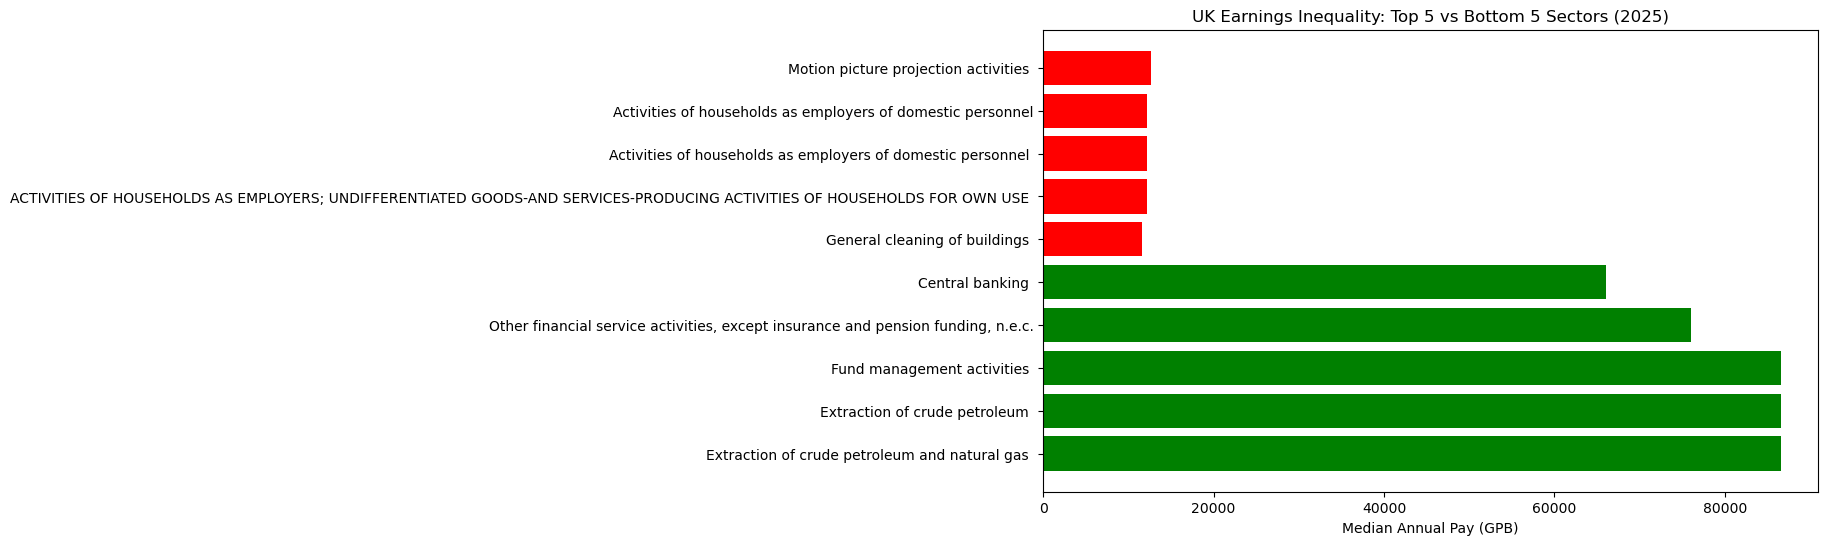

In [16]:
import matplotlib.pyplot as plt

# Combine top and bottom 5 for comparison
top5 = df_clean_unique.nlargest(5, 'Median')
bottom5 = df_clean_unique.nsmallest(5, 'Median')
combined = pd.concat([top5, bottom5])

# Plot
plt.figure(figsize=(10, 6))
plt.barh(combined['Description'], combined['Median'], color=['green' if x > 30000 else 'red' for x in combined['Median']])
plt.xlabel('Median Annual Pay (GPB)')
plt.title('UK Earnings Inequality: Top 5 vs Bottom 5 Sectors (2025)')
plt.tight_layout()
plt.show()
          







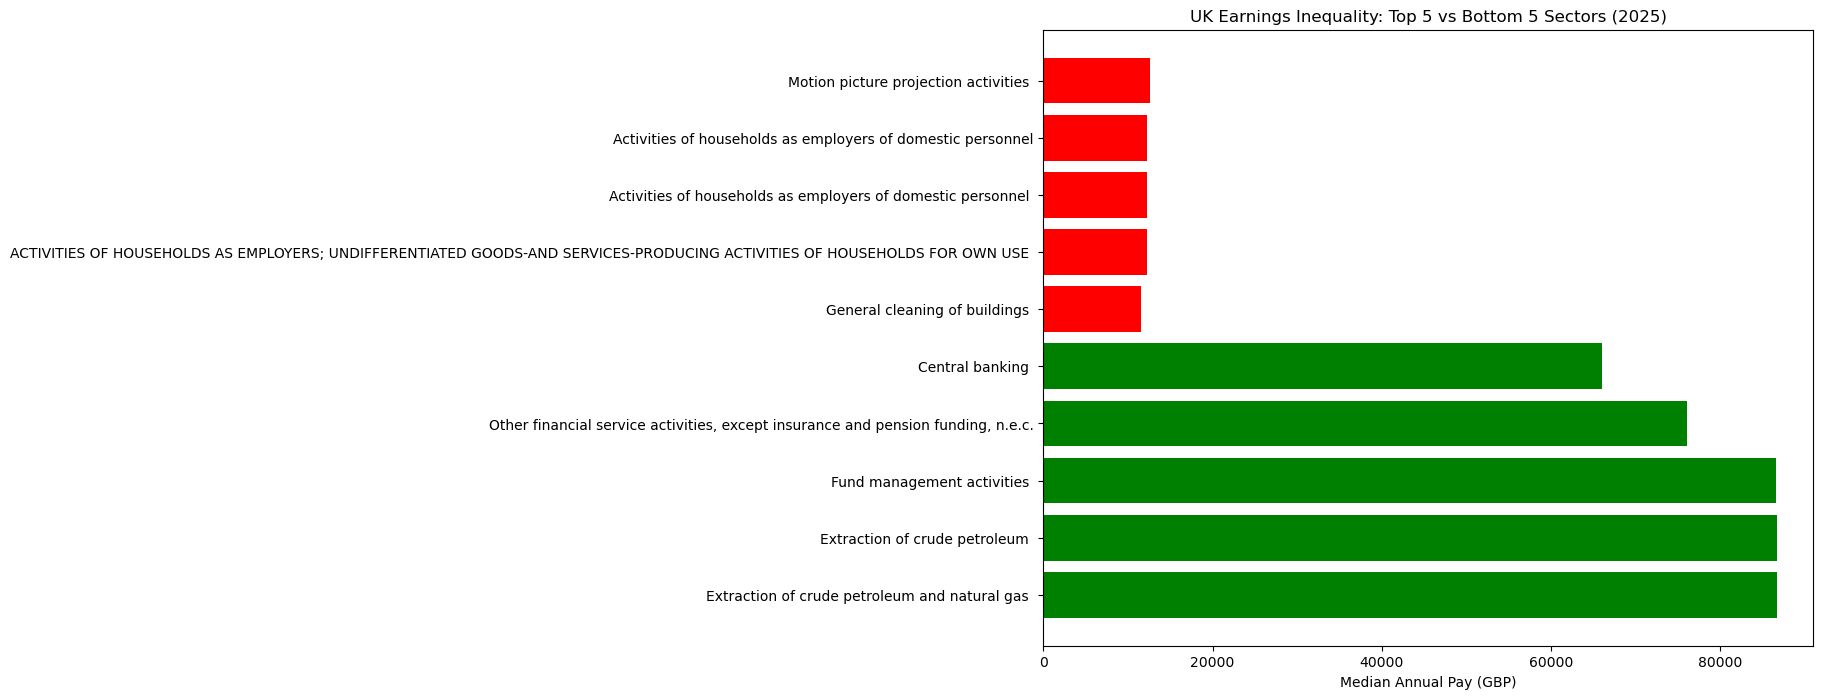

In [22]:
plt.figure(figsize=(14, 8))
plt.barh(combined['Description'], combined['Median'],
         color=['green' if x > 30000 else 'red' for x in combined['Median']])
plt.xlabel('Median Annual Pay (GBP)')
plt.title('UK Earnings Inequality: Top 5 vs Bottom 5 Sectors (2025)')
plt.subplots_adjust(left=0.35)
plt.show()        








In [2]:
print ('Description:' [5], 'Median:' [5])




i n


In [3]:
df[['Description', 'Median']].head(5)

NameError: name 'df' is not defined

In [7]:
import pandas as pd
df = pd.read_excel("/Users/sajidhaikh/Documents/Research/ONS_Annual_Pay_Gross_2025.xlsx", 
                   sheet_name="All",
                   header=4)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/sajidhaikh/Documents/Research/ONS_Annual_Pay_Gross_2025.xlsx'

In [8]:
import pandas as pd

df = pd.read_excel("/Users/sajidhaikh/Documents/Research/ONS_Annual_Pay_Gross_2025.xlsx",
                   sheet_name="All",
                   header=4)

print(df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/sajidhaikh/Documents/Research/ONS_Annual_Pay_Gross_2025.xlsx'

In [9]:
df = pd.read_excel("/Users/sajidhaikh/Desktop/ONS_Annual_Pay_Gross_2025.xlsx",
                   sheet_name="All",
                   header=4)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/sajidhaikh/Desktop/ONS_Annual_Pay_Gross_2025.xlsx'

In [10]:
import pandas as pd
import os

filepath = os.path.expanduser("~/Desktop/ONS_Annual_Pay_Gross_2025.xlsx")
print(filepath)

df = pd.read_excel(filepath, sheet_name="All", header=4)
print(df.shape)







/Users/sajidshaikh/Desktop/ONS_Annual_Pay_Gross_2025.xlsx
(1007, 20)


In [12]:
df[['Description', 'Median']].head(5)



,Description,Median
0,ALL EMPLOYEES,32890
1,All Industries and Services,32894
2,All Index of Production Industries,38199
3,All Manufacturing,37297
4,All Service Industries,31845


In [14]:
df[['Description', 'Median', 'change']].tail(8)

,Description,Median,change
999,Activities of extraterritorial organisations a...,39417,NaN
1000,Activities of extraterritorial organisations a...,39417,NaN
1001,NOT CLASSIFIED,x,NaN
1002,a Employees on adult rates who have been in t...,NaN,NaN
1003,b Figures for Number of Jobs are for indicati...,NaN,NaN
1004,KEY - The colour coding indicates the quality ...,NaN,NaN
1005,The quality of an estimate is measured by its ...,NaN,NaN
1006,"Source: Annual Survey of Hours and Earnings, O...",NaN,NaN


In [15]:
df_clean_unique.tail(8)

,Description,Median,change
981,Other personal service activities,23443,7.4
983,Washing and (dry-)cleaning of textile and fur ...,23747,-3.0
984,Hairdressing and other beauty treatment,14988,4.9
985,Funeral and related activities,29601,9.8
987,Other personal service activities n.e.c,28215,9.3
988,ACTIVITIES OF HOUSEHOLDS AS EMPLOYERS; UNDIFFE...,12226,5.5
989,Activities of households as employers of domes...,12226,5.5
990,Activities of households as employers of domes...,12226,5.5


In [16]:
df_clean_unique.nlargest(5, 'Description', 'Median', 'change')







TypeError: DataFrame.nlargest() takes from 3 to 4 positional arguments but 5 were given

In [18]:
df_clean_unique.nlargest(5, 'change')[['Description', 'Median', 'change']]









,Description,Median,change
485,Construction of bridges and tunnels,64154,38.8
405,Manufacture of motorcycles,41720,38.2
327,Manufacture of computers and peripheral equipm...,42730,35.5
328,Manufacture of computers and peripheral equipment,42730,35.5
746,"Other financial service activities, except ins...",76041,33.1


In [20]:
df_clean_unique.nsmallest(5, 'change') [['Description', 'Median', 'change']]






    

,Description,Median,change
357,Manufacture of other electrical equipment,30835,-34.5
704,Motion picture projection activities,12645,-24.8
226,Manufacture of man-made fibres,34608,-23.4
684,Event catering activities,16446,-21.5
614,Retail sale of cosmetic and toilet articles in...,20567,-13.4


In [ ]:
AI is having a disproportionate impact on pay parity, creating winners and losers in sectors where adoption is natural progressiona and results in productivity gains, as opposed to sectors that still depend more on physical labour than AI adoption. AI is making a material difference, acting as a catalyst in high-end sectors and remaining inert at the lower end of the work spectrum. 

In [3]:

# FINDING — Session 6, June 2026
# AI is having a disproportionate impact on pay parity, creating winners 
# and losers in sectors where adoption is natural progression and results 
# in productivity gains, as opposed to sectors that still depend more on 
# physical labour. AI is acting as a catalyst in high-end sectors and 
# remaining inert at the lower end of the work spectrum.
# 
# Key question: is this natural progression or a structural choice?
# Policy implication: intervention may be possible if adoption is chosen,
# not inevitable.


            



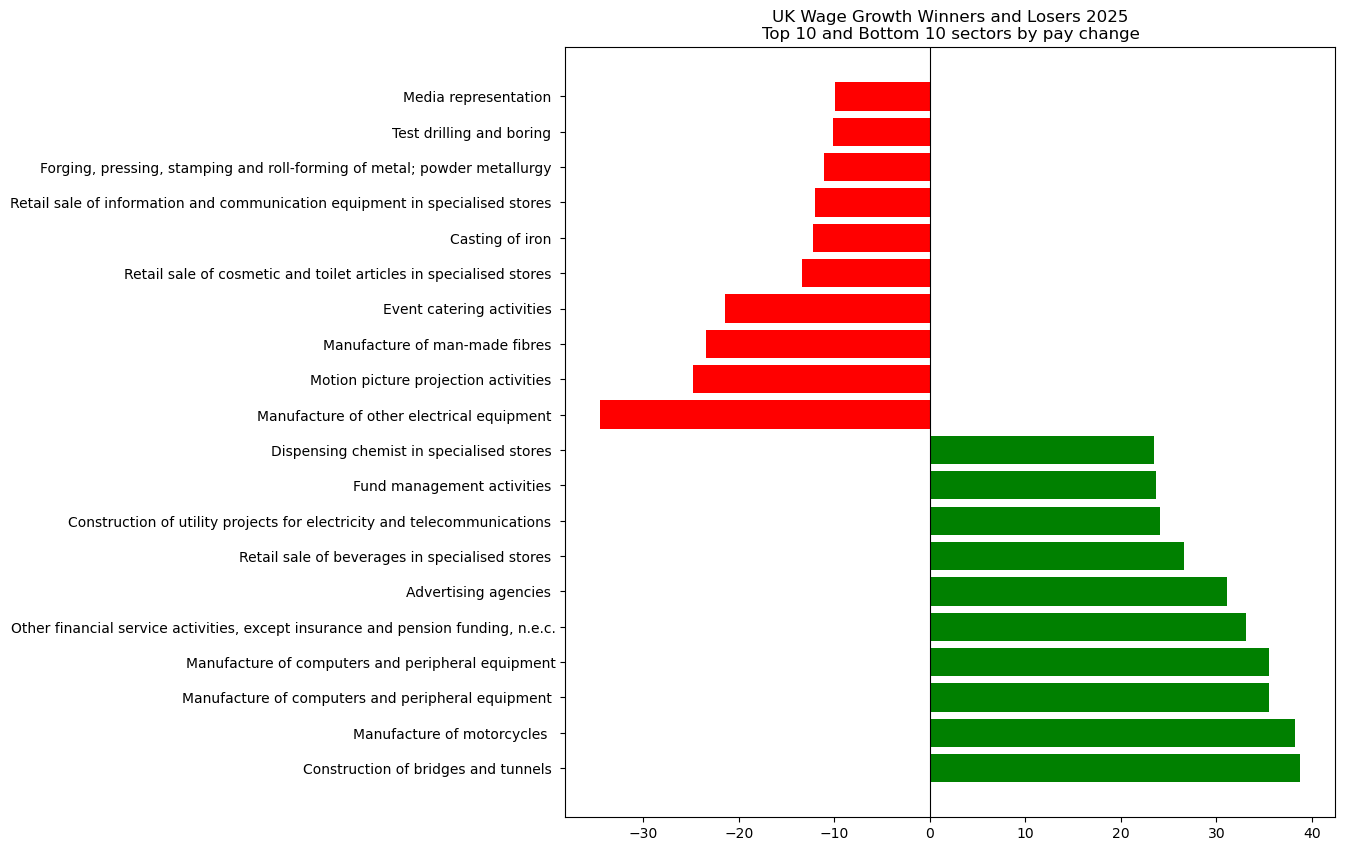

In [5]:
import matplotlib.pyplot as plt

# Get top 10 and bottom 10 by wage growth
top10_growth = df_clean_unique.nlargest(10, 'change')
bottom10_growth = df_clean_unique.nsmallest(10, 'change')
combined_growth = pd.concat([top10_growth, bottom10_growth])

#Plot
fig, ax = plt.subplots(figsize=(14,10))
colors = ['green' if x > 0 else 'red' for x in combined_growth['change']]
ax.barh(combined_growth['Description'], combined_growth['change'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('UK Wage Growth Winners and Losers 2025\nTop 10 and Bottom 10 sectors by pay change')
plt.subplots_adjust(left=0.35)
plt.show()















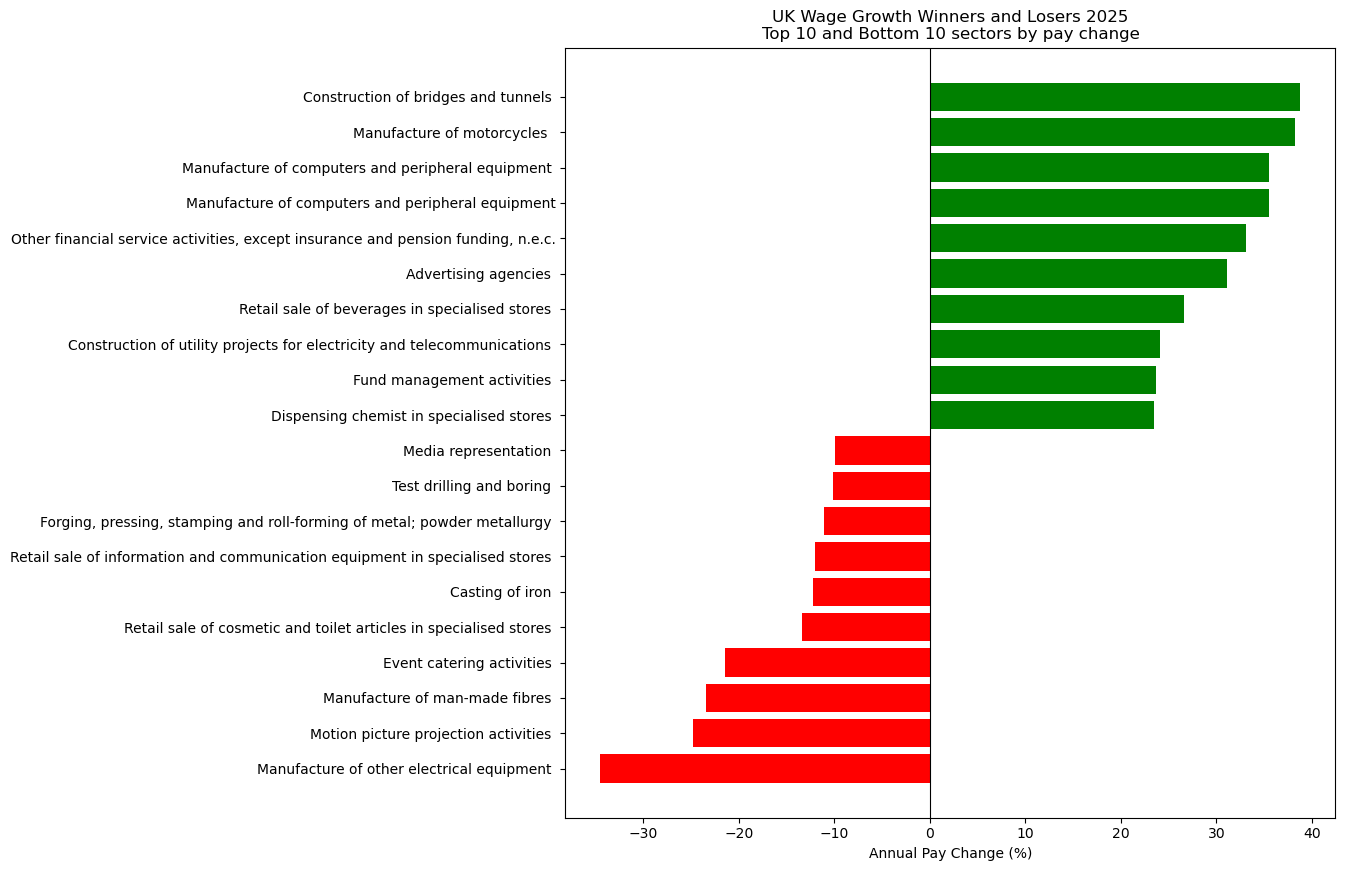

In [6]:
#Sort combined data by change for cleaner visualisation
combined_sorted = combined_growth.sort_values ('change')

fig, ax = plt.subplots(figsize=(14, 10))
colors = ['green' if x > 0 else 'red' for x in combined_sorted['change']]
ax.barh(combined_sorted['Description'], combined_sorted['change'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Annual Pay Change (%)')
ax.set_title('UK Wage Growth Winners and Losers 2025\nTop 10 and Bottom 10 sectors by pay change')
plt.subplots_adjust(left=0.35)
plt.show()















Chart saved to Desktop


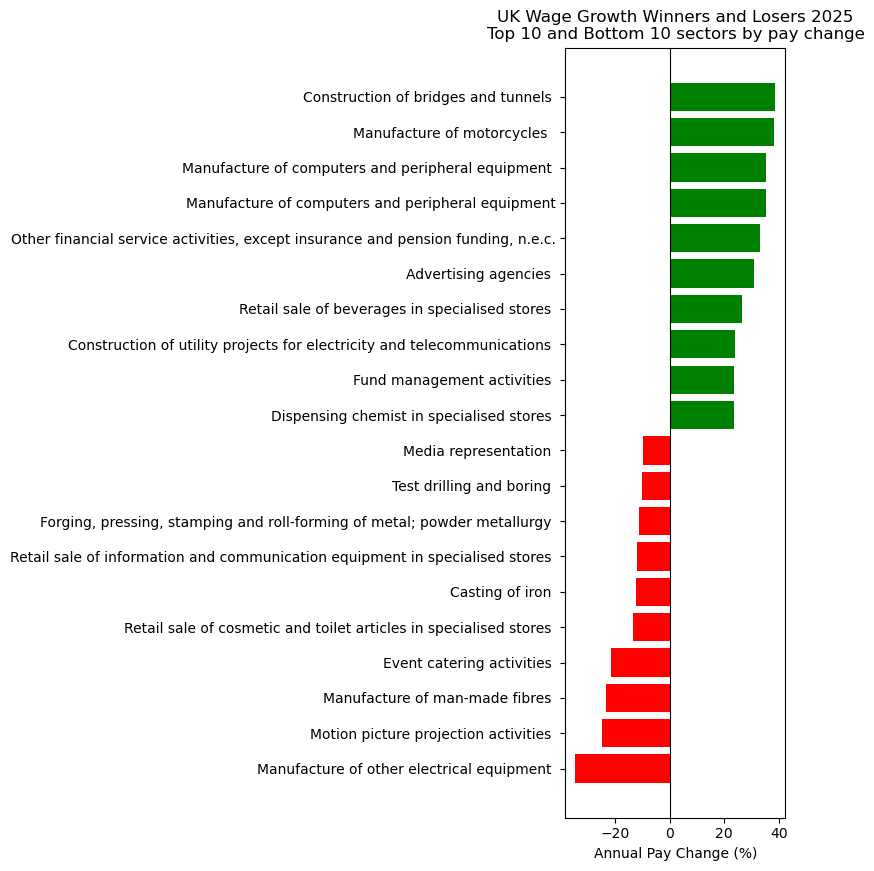

In [8]:
fig, ax = plt.subplots(figsize=(4, 10))
colors = ['green' if x > 0 else 'red' for x in combined_sorted['change']]
ax.barh(combined_sorted['Description'], combined_sorted['change'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Annual Pay Change (%)')
ax.set_title('UK Wage Growth Winners and Losers 2025\nTop 10 and Bottom 10 sectors by pay change')    
plt.subplots_adjust(left=0.35)
plt.savefig(os.path.expanduser("~/Desktop/wage_growth_chart.png"), 
            dpi=150, bbox_inches='tight')
print("Chart saved to Desktop")










In [10]:
# Strip whitespace from Description and deduplicate again
df_clean_unique['Description'] = df_clean_unique['Description'].str.strip()
df_clean_unique = df_clean_unique.drop_duplicates(subset=['Description'])

# Verify computers is now single 
print(df_clean_unique[df_clean_unique['Description'].str.contains('computers')][['Description', 'Median', 'change']])










                                           Description  Median  change
327  Manufacture of computers and peripheral equipment   42730    35.5
559  Wholesale of computers, computer peripheral eq...   47215    -0.4
970  Repair of computers and personal and household...   37709     6.6
971    Repair of computers and communication equipment   46627    18.1
972       Repair of computers and peripheral equipment   46945    17.2


Chart saved to Desktop


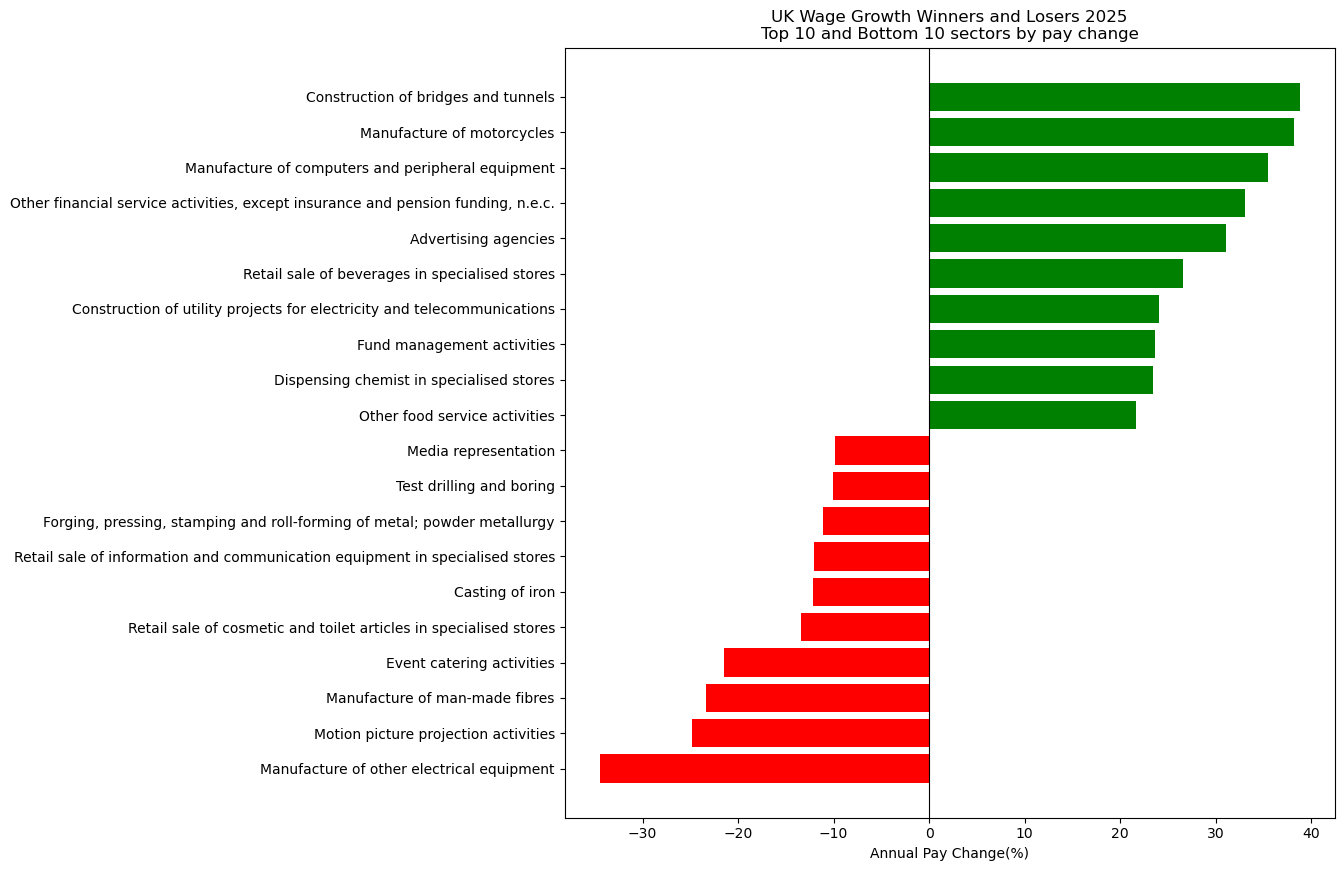

In [14]:
# Regenerate with clean dedpulicated data
top10_growth = df_clean_unique.nlargest(10, 'change')
bottom10_growth = df_clean_unique.nsmallest(10, 'change')
combined_sorted = pd.concat([top10_growth, bottom10_growth]).sort_values('change')

# Plot and save 
fig, ax = plt.subplots(figsize=(14, 10))
colors = ['green' if x > 0 else 'red' for x in combined_sorted['change']]
ax.barh(combined_sorted['Description'], combined_sorted['change'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Annual Pay Change(%)')
ax.set_title('UK Wage Growth Winners and Losers 2025\nTop 10 and Bottom 10 sectors by pay change')
plt.subplots_adjust(left=0.35)
plt.savefig(os.path.expanduser("~/Desktop/wage_growth_chart_final.png"), 
            dpi=150, bbox_inches='tight')
print("Chart saved to Desktop")
plt.show()




















In [2]:
print (df_clean_unique(['Median'], ['sector.mean']()

_IncompleteInputError: incomplete input (167628902.py, line 1)

In [6]:
print (df_clean_unique['Median'].mean())

36071.484375


In [10]:
print (df_clean_unique['change'].mean())
print (df_clean_unique['change'].max())

5.0725694444444445
38.8


In [14]:
print (df_clean_unique['change'].min())
print (df_clean_unique['change'].max())




-34.5
38.8
